# EVA — VLM predictions vs. ground-truth labels

A focused, single-run comparison: the **VLM model output** (`persona · T=0.7`, `data/logs_t_0.7`) against the **ground-truth EVA labels** each real voter gave (the `gt_*` fields stored alongside every prediction in the result JSON).

**Dataset.** ~137k filtered ballots over 4,000 photographs (~30+ voters each); voters carry birth year, region, gender, photographic level and eyesight. 6 axes: an overall `score` (0-10) plus five 1-4 sub-axes. Scale: score 0-10, sub-axes 1-4.

Each record is one `(photograph, voter, axis)` triple: `pred_<axis>` is what the VLM said role-playing that voter, `gt_<axis>` is that voter's actual rating. Everything below lines the two up — per rating, per score level (calibration), and per photograph.

*All EVA axes are whole-number grids, so the confusion heatmaps use the raw score levels (11x11 for `score`, 4x4 for the sub-axes).*

In [1]:
import glob
import json
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

BLUE, AQUA, AMBER = "#2a78d6", "#1baf7a", "#d98a1f"
INK, SECONDARY, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
HUMAN_FILL = "#d9d7cd"
GOOD, CRITICAL = "#0ca30c", "#d03b3b"
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#f4f6f9", "#9dc0e8", "#2a78d6", "#0f3f7d"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.labelcolor": SECONDARY, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.labelsize": 10, "legend.fontsize": 9, "legend.frameon": False,
    "figure.dpi": 110, "lines.linewidth": 2, "font.size": 10,
})
pd.set_option("display.width", 170, "display.max_columns", 60, "display.float_format", lambda v: f"{v:.3f}")

In [2]:
# ---- dataset configuration ----
DATASET = "EVA"
LOG_DIR, STEM = "../data/logs_t_0.7", "eva_full"   # persona-conditioned, temperature 0.7
PRIMARY = "score"
RATER_WORD, ITEM_WORD = "voter", "photograph"
TOL, TOL_LABEL = 1.0, "within 1"    # hit-rate tolerance on this dataset's scale
MIN_N = 15                               # min raters per image for the examples table
print(f"{DATASET} | {STEM} | tolerance: {TOL_LABEL}")

EVA | eva_full | tolerance: within 1


## Load the run

In [3]:
def _main_shards(dirp, stem):
    fs = sorted(glob.glob(os.path.join(dirp, f"{stem}.shard*of*.json")))
    return [f for f in fs if ".part-" not in f]


def load_condition(dirp, stem):
    """Raw (image, rater) records: pred_<axis> = the VLM's answer, gt_<axis> = the real label
    that rater gave. Records live in the .part-*.json chunks the manifest lists."""
    shards = _main_shards(dirp, stem)
    if not shards:
        raise FileNotFoundError(f"no shards for {stem} under {dirp}")
    recs, grids, cfg = [], {}, None
    for mf in shards:
        d = json.load(open(mf))
        cfg = d
        for dim, dm in d["metrics"]["per_dimension"].items():
            grids.setdefault(dim, dm["distribution"]["score_grid"])
        for part in d["result_parts"]:
            for r in json.load(open(os.path.join(dirp, part))):
                recs.append({k: v for k, v in r.items() if k not in ("comment", "raw_response")})
    dims = [x["name"] if isinstance(x, dict) else x for x in cfg["dimensions"]]
    df = pd.DataFrame(recs)
    for dim in dims:
        for pfx in ("gt_", "pred_"):
            df[pfx + dim] = pd.to_numeric(df[pfx + dim], errors="coerce")
    return df, dims, grids, cfg


DF, DIMS, GRIDS, CFG = load_condition(LOG_DIR, STEM)
print(f"model run: {CFG['model_name']}  |  temperature {CFG['temperature']}  |  {CFG['generated_at'][:19]}")
print(f"ratings: {len(DF):,}   images: {DF['imageName'].nunique():,}   {RATER_WORD}s: {DF['userId'].nunique():,}")
cnt = DF.groupby("imageName").size()
print(f"raters per image: min {cnt.min()}  median {int(cnt.median())}  max {cnt.max()}")
print(f"axes ({len(DIMS)}):", ", ".join(DIMS))
for d in DIMS:
    g = GRIDS[d]
    print(f"   {d}: label grid {g[0]:g}..{g[-1]:g} ({len(g)} levels)")

model run: Qwen/Qwen2-VL-7B-Instruct  |  temperature 0.7  |  2026-07-14T14:00:47
ratings: 134,576   images: 4,000   voters: 1,094
raters per image: min 30  median 33  max 46
axes (6): score, visual, composition, quality, semantic, difficulty
   score: label grid 0..10 (11 levels)
   visual: label grid 1..4 (4 levels)
   composition: label grid 1..4 (4 levels)
   quality: label grid 1..4 (4 levels)
   semantic: label grid 1..4 (4 levels)
   difficulty: label grid 1..4 (4 levels)


In [4]:
# How many (image, rater, axis) predictions actually parsed? (unparsed -> NaN, dropped below.)
cov = pd.DataFrame({
    dim: {"ratings": len(DF),
          "parsed": int(DF[f"pred_{dim}"].notna().sum()),
          "parse_rate": DF[f"pred_{dim}"].notna().mean()}
    for dim in DIMS}).T
cov["parse_rate"] = cov["parse_rate"].round(4)
cov

,ratings,parsed,parse_rate
score,134576.000,134576.000,1.000
visual,134576.000,134576.000,1.000
composition,134576.000,134576.000,1.000
quality,134576.000,134576.000,1.000
semantic,134576.000,134576.000,1.000
difficulty,134576.000,134576.000,1.000


In [5]:
def paired(df, dim):
    return (df[["imageName", f"gt_{dim}", f"pred_{dim}"]]
            .rename(columns={f"gt_{dim}": "gt", f"pred_{dim}": "pred"}).dropna())


def agreement(df, dim):
    p = paired(df, dim)
    gt, pr = p["gt"].to_numpy(), p["pred"].to_numpy()
    err = pr - gt
    img_mean = p.groupby("imageName")["gt"].transform("mean").to_numpy()
    return dict(
        n=len(p), mae=np.abs(err).mean(), rmse=np.sqrt((err ** 2).mean()), bias=err.mean(),
        pearson=stats.pearsonr(pr, gt)[0], spearman=stats.spearmanr(pr, gt)[0],
        exact=np.mean(np.isclose(err, 0.0)),          # prediction lands exactly on the label
        within_tol=np.mean(np.abs(err) <= TOL),       # within TOL of the label
        label_noise_mae=np.abs(gt - img_mean).mean(), # floor: predict each image's own mean label
    )


def axis_bins(dim):
    # confusion buckets: raw score levels for coarse grids, 10 equal bins for fine ones (e.g. 0-100)
    grid = np.asarray(GRIDS[dim], float)
    if len(grid) <= 15:
        step = np.median(np.diff(grid)) if len(grid) > 1 else 1.0
        return np.concatenate([grid - step / 2, [grid[-1] + step / 2]]), [f"{g:g}" for g in grid]
    edges = np.linspace(grid[0], grid[-1], 11)
    return edges, [f"{edges[i]:.0f}-{edges[i + 1]:.0f}" for i in range(len(edges) - 1)]


def confusion(df, dim):
    # P(prediction | true label): columns are true labels, rows predictions, columns sum to 1
    edges, labels = axis_bins(dim)
    p = paired(df, dim)
    ti = np.clip(np.digitize(p["gt"].to_numpy(), edges) - 1, 0, len(labels) - 1)
    qi = np.clip(np.digitize(p["pred"].to_numpy(), edges) - 1, 0, len(labels) - 1)
    M = np.zeros((len(labels), len(labels)))
    np.add.at(M, (qi, ti), 1)
    col = M.sum(axis=0, keepdims=True)
    return np.divide(M, col, out=np.zeros_like(M), where=col > 0), labels, col.ravel()


def err_edges(dim):
    grid = np.asarray(GRIDS[dim], float)
    R = grid[-1] - grid[0]
    step = np.median(np.diff(grid)) if len(grid) > 1 else 1.0
    if len(grid) <= 15:
        return np.arange(-R - step / 2, R + step, step)
    return np.linspace(-R, R, 41)


def hist_on_grid(vals, grid):
    grid = np.asarray(grid, float)
    if len(grid) > 25:
        edges = np.linspace(grid[0], grid[-1], 26)
        centers = 0.5 * (edges[:-1] + edges[1:])
    else:
        step = np.median(np.diff(grid)) if len(grid) > 1 else 1.0
        edges = np.concatenate([grid - step / 2, [grid[-1] + step / 2]])
        centers = grid
    h, _ = np.histogram(np.asarray(vals, float), bins=edges)
    tot = h.sum()
    w = float(np.median(np.diff(centers))) if len(centers) > 1 else 1.0
    return centers, (h / tot if tot else h), w


def grid_shape(n):
    ncol = 1 if n == 1 else (2 if n <= 4 else 3)
    return int(np.ceil(n / ncol)), ncol

## 1 - How close is each prediction to its label?

`within_tol` (within 1) and `exact` are the intuitive hit rates; `mae`/`rmse` the average miss; `bias` the direction (+ = model rates above the human). `label_noise_mae` is the reference floor — the error from just predicting each photograph's own mean label, i.e. how much the voters disagree among themselves.

In [6]:
agree = pd.DataFrame({dim: agreement(DF, dim) for dim in DIMS}).T
agree = agree[["n", "mae", "rmse", "bias", "pearson", "spearman", "exact", "within_tol", "label_noise_mae"]]
print(f"{DATASET}: VLM prediction vs ground-truth label, per axis.")
print(f"exact = fraction landing on the label; within_tol = {TOL_LABEL};")
print("label_noise_mae = error from just predicting each image's mean label.\n")
agree

EVA: VLM prediction vs ground-truth label, per axis.
exact = fraction landing on the label; within_tol = within 1;
label_noise_mae = error from just predicting each image's mean label.



,n,mae,rmse,bias,pearson,spearman,exact,within_tol,label_noise_mae
score,134576.000,1.697,2.234,0.869,0.275,0.280,0.202,0.549,1.423
visual,134576.000,0.960,1.187,0.924,0.206,0.201,0.253,0.799,0.495
composition,134576.000,0.561,0.825,0.267,0.128,0.122,0.496,0.945,0.511
quality,134576.000,0.528,0.811,0.386,0.162,0.153,0.535,0.941,0.410
semantic,134576.000,0.523,0.804,0.326,0.138,0.137,0.536,0.944,0.449
difficulty,134576.000,0.528,0.788,0.282,0.017,0.016,0.518,0.954,0.357


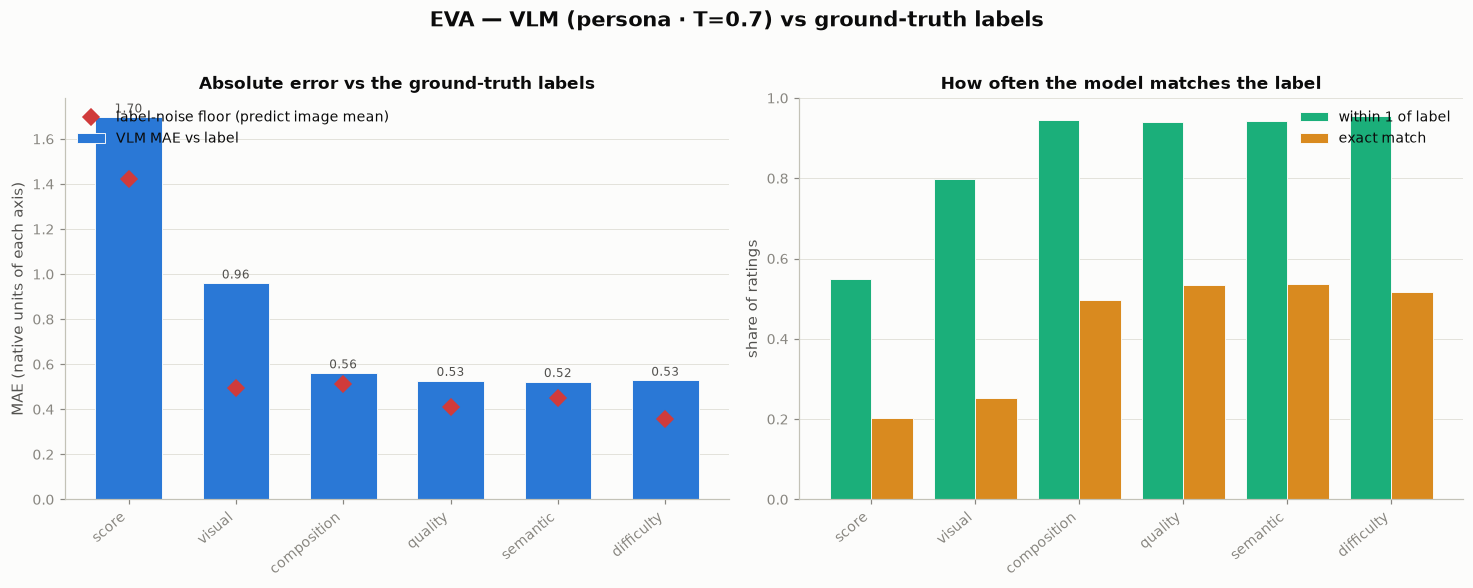

In [7]:
x = np.arange(len(DIMS))
fig, (axl, axr) = plt.subplots(1, 2, figsize=(13.5, 5.2))
mae = [agreement(DF, d)["mae"] for d in DIMS]
floor = [agreement(DF, d)["label_noise_mae"] for d in DIMS]
axl.bar(x, mae, 0.62, color=BLUE, label="VLM MAE vs label", edgecolor=SURFACE, linewidth=0.6)
axl.plot(x, floor, "D", color=CRITICAL, ms=7, label="label-noise floor (predict image mean)")
for xi, m in zip(x, mae):
    axl.annotate(f"{m:.2f}", (xi, m), textcoords="offset points", xytext=(0, 3), ha="center",
                 fontsize=8, color=SECONDARY)
axl.set_title("Absolute error vs the ground-truth labels")
axl.set_ylabel("MAE (native units of each axis)")
axl.set_xticks(x, DIMS, rotation=40, ha="right"); axl.xaxis.grid(False); axl.legend(loc="upper left")
wt = [agreement(DF, d)["within_tol"] for d in DIMS]
ex = [agreement(DF, d)["exact"] for d in DIMS]
axr.bar(x - 0.2, wt, 0.4, color=AQUA, label=f"{TOL_LABEL} of label", edgecolor=SURFACE, linewidth=0.6)
axr.bar(x + 0.2, ex, 0.4, color=AMBER, label="exact match", edgecolor=SURFACE, linewidth=0.6)
axr.set_title("How often the model matches the label"); axr.set_ylabel("share of ratings"); axr.set_ylim(0, 1)
axr.set_xticks(x, DIMS, rotation=40, ha="right"); axr.xaxis.grid(False); axr.legend(loc="upper right")
fig.suptitle(f"{DATASET} — VLM (persona · T=0.7) vs ground-truth labels", fontsize=14,
             fontweight="bold", color=INK, y=1.02)
fig.tight_layout(); plt.show()

## 2 - Calibration: prediction vs. true label

Column-normalised confusion: for every true label on the x-axis, the vertical strip shows how the model's predictions are distributed. A calibrated model hugs the red diagonal; mass above it means the model inflates that label, below means it deflates.

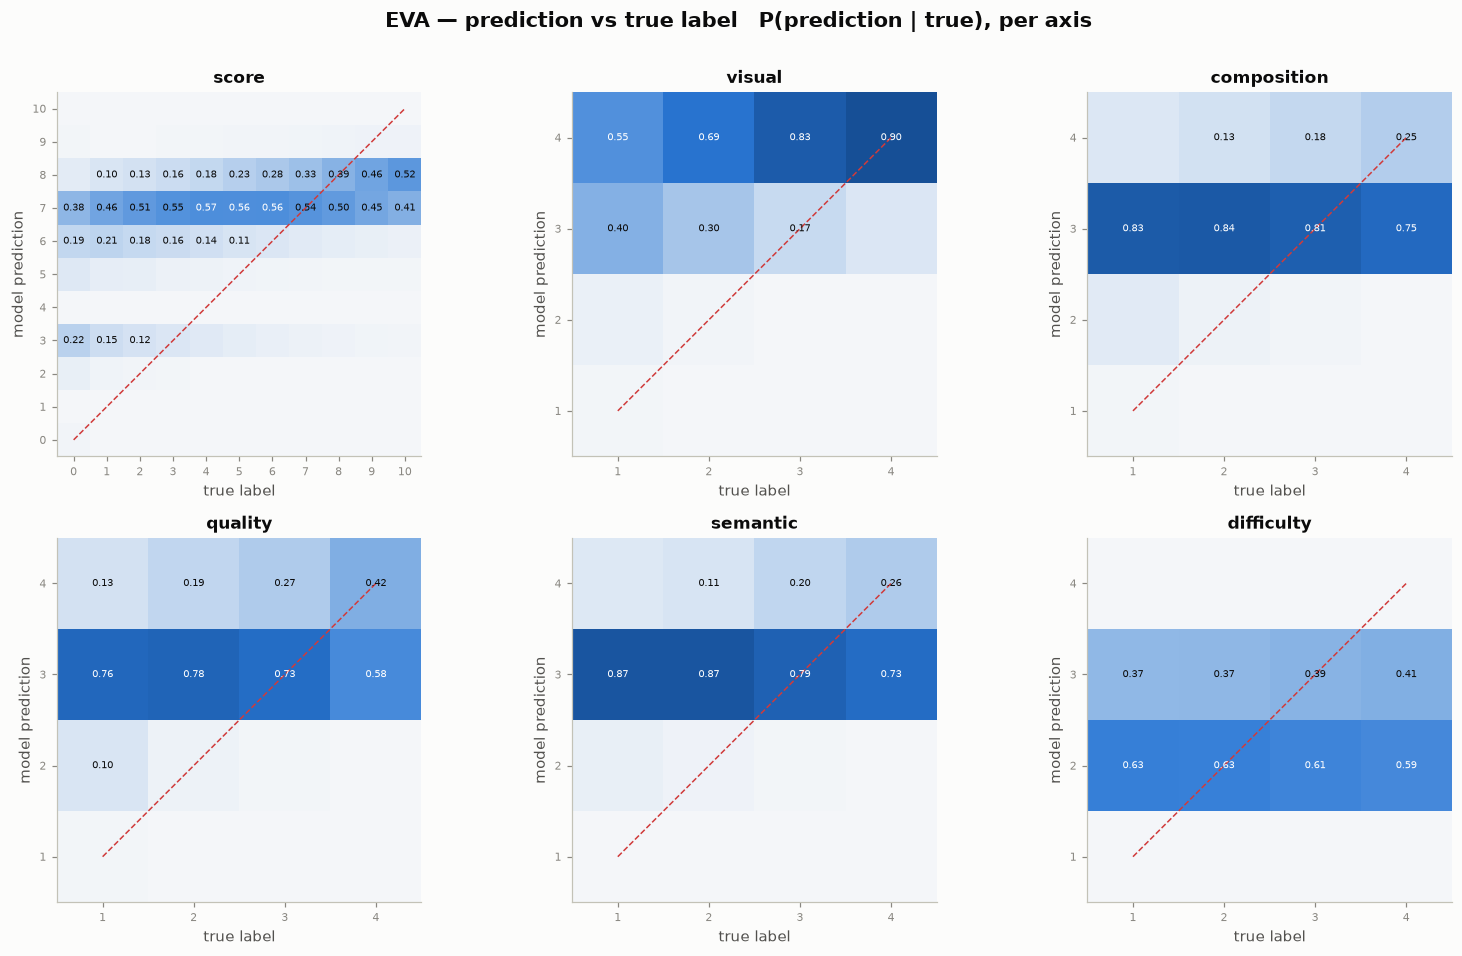

In [8]:
nr, nc = grid_shape(len(DIMS))
fig, axes = plt.subplots(nr, nc, figsize=(4.8 * nc, 4.3 * nr), squeeze=False)
for ax, dim in zip(axes.flat, DIMS):
    M, labels, _ = confusion(DF, dim)
    ax.imshow(M, cmap=SEQ, vmin=0, vmax=1, origin="lower", aspect="equal")
    ax.plot([0, len(labels) - 1], [0, len(labels) - 1], color=CRITICAL, lw=1, ls="--")
    fs = 7 if len(labels) <= 11 else 6
    rot = 45 if len(labels[0]) > 3 else 0
    ax.set_xticks(range(len(labels)), labels, fontsize=fs, rotation=rot,
                  ha="right" if rot else "center")
    ax.set_yticks(range(len(labels)), labels, fontsize=fs)
    if len(labels) <= 11:
        for a in range(len(labels)):
            for b in range(len(labels)):
                if M[a, b] >= 0.10:
                    ax.annotate(f"{M[a, b]:.2f}", (b, a), ha="center", va="center", fontsize=6.5,
                                color="#ffffff" if M[a, b] > 0.55 else INK)
    ax.set_title(dim); ax.grid(False)
    ax.set_xlabel("true label"); ax.set_ylabel("model prediction")
for ax in axes.flat[len(DIMS):]:
    ax.set_visible(False)
fig.suptitle(f"{DATASET} — prediction vs true label   P(prediction | true), per axis",
             fontsize=14, fontweight="bold", color=INK, y=1.005)
fig.tight_layout(); plt.show()

## 3 - Error distribution

The signed gap `prediction - label` per axis. Symmetric around the dashed zero line = unbiased; the red line marks the mean.

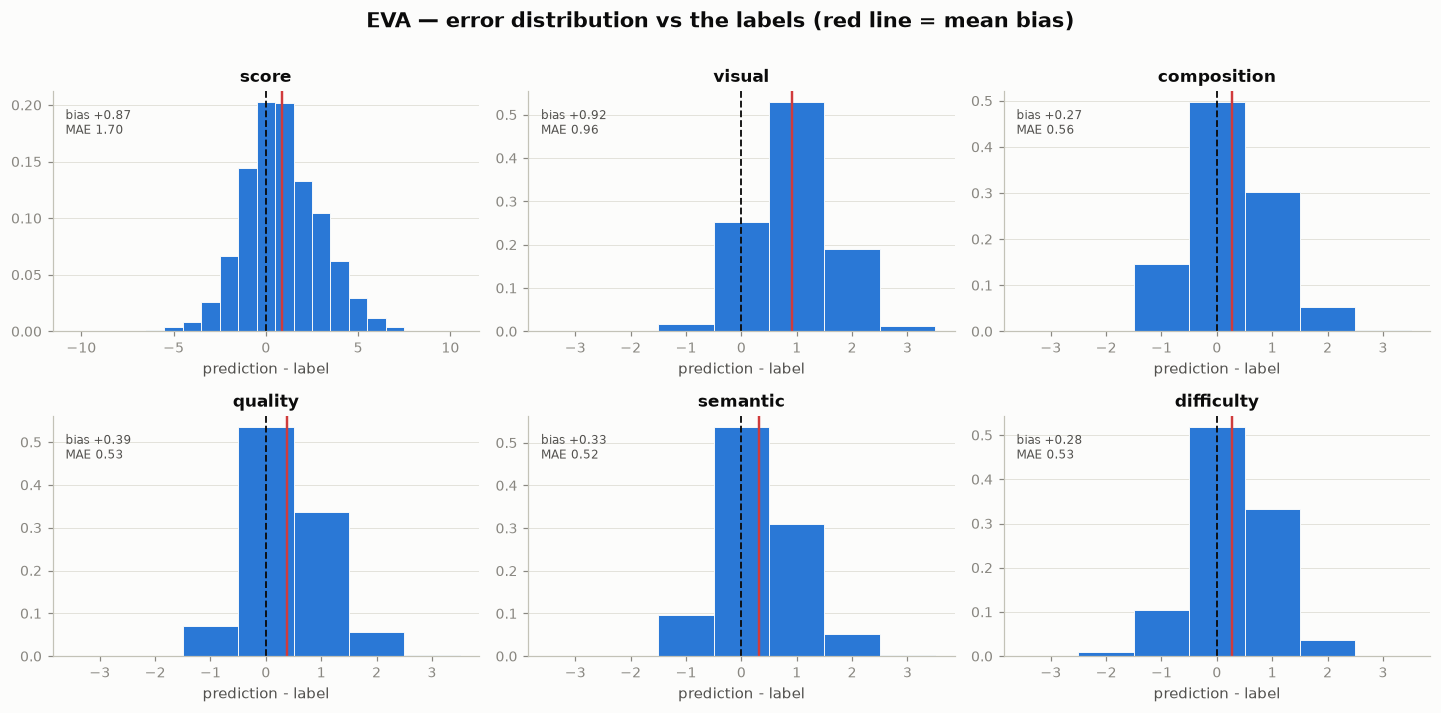

In [9]:
nr, nc = grid_shape(len(DIMS))
fig, axes = plt.subplots(nr, nc, figsize=(4.4 * nc, 3.2 * nr), squeeze=False)
for ax, dim in zip(axes.flat, DIMS):
    p = paired(DF, dim)
    err = (p["pred"] - p["gt"]).to_numpy()
    w = np.ones_like(err) / len(err)
    ax.hist(err, bins=err_edges(dim), weights=w, color=BLUE, edgecolor=SURFACE, linewidth=0.6)
    ax.axvline(0, color=INK, lw=1.2, ls="--"); ax.axvline(err.mean(), color=CRITICAL, lw=1.6)
    ax.annotate(f"bias {err.mean():+.2f}\nMAE {np.abs(err).mean():.2f}", xy=(0.03, 0.93),
                xycoords="axes fraction", va="top", fontsize=8, color=SECONDARY)
    ax.set_title(dim); ax.xaxis.grid(False); ax.set_xlabel("prediction - label")
for ax in axes.flat[len(DIMS):]:
    ax.set_visible(False)
fig.suptitle(f"{DATASET} — error distribution vs the labels (red line = mean bias)",
             fontsize=14, fontweight="bold", color=INK, y=1.005)
fig.tight_layout(); plt.show()

## 4 - Marginal distributions

Where the labels land versus where the model puts its scores — the bias of section 1 seen as whole distributions.

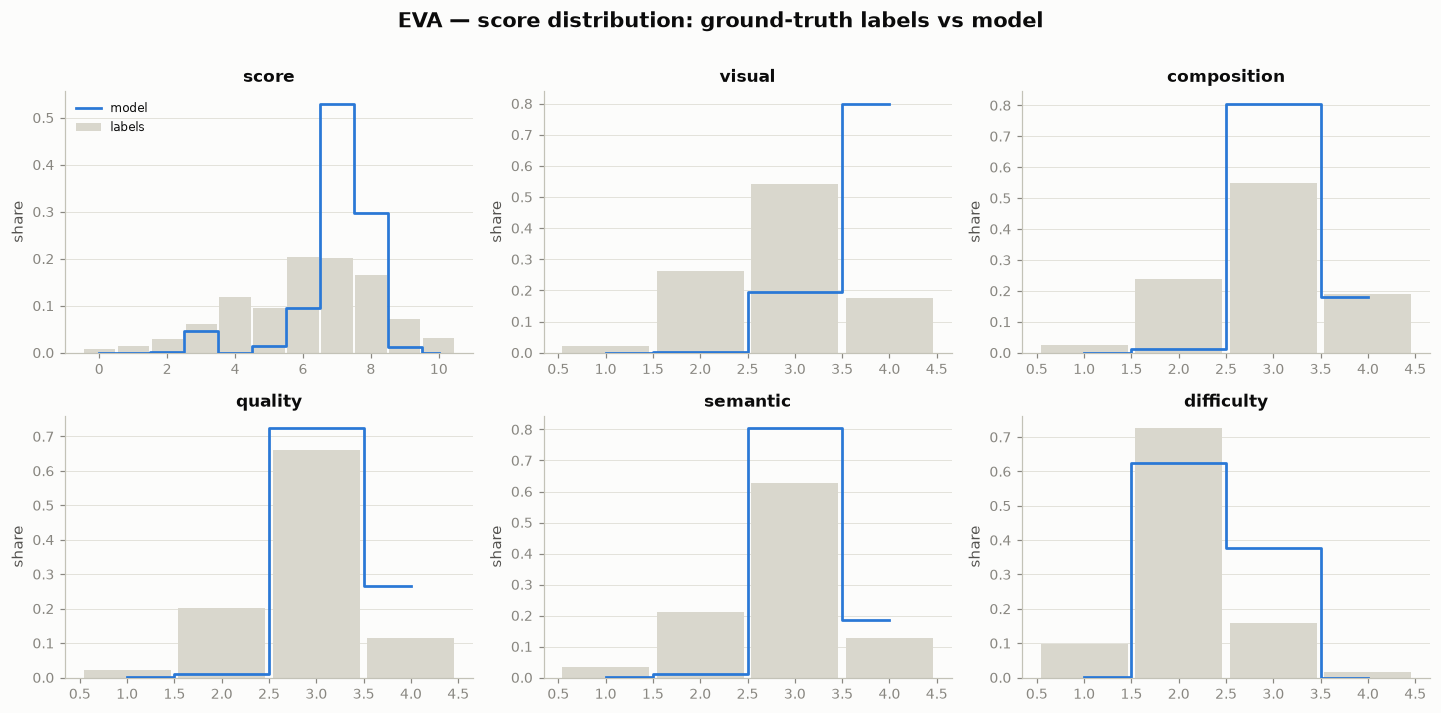

In [10]:
nr, nc = grid_shape(len(DIMS))
fig, axes = plt.subplots(nr, nc, figsize=(4.4 * nc, 3.2 * nr), squeeze=False)
for ax, dim in zip(axes.flat, DIMS):
    p = paired(DF, dim)
    c, hh, w = hist_on_grid(p["gt"], GRIDS[dim])
    ax.bar(c, hh, width=w * 0.92, color=HUMAN_FILL, label="labels", zorder=1)
    c2, hm, _ = hist_on_grid(p["pred"], GRIDS[dim])
    ax.step(c2, hm, where="mid", color=BLUE, lw=1.8, label="model", zorder=3)
    ax.set_title(dim); ax.xaxis.grid(False); ax.set_ylabel("share")
for ax in axes.flat[len(DIMS):]:
    ax.set_visible(False)
axes.flat[0].legend(loc="upper left", fontsize=8)
fig.suptitle(f"{DATASET} — score distribution: ground-truth labels vs model",
             fontsize=14, fontweight="bold", color=INK, y=1.005)
fig.tight_layout(); plt.show()

## 5 - Per-photograph agreement

Averaging each photograph's voters removes rating-level noise and isolates whether the model *orders photographs* the way the labels do.

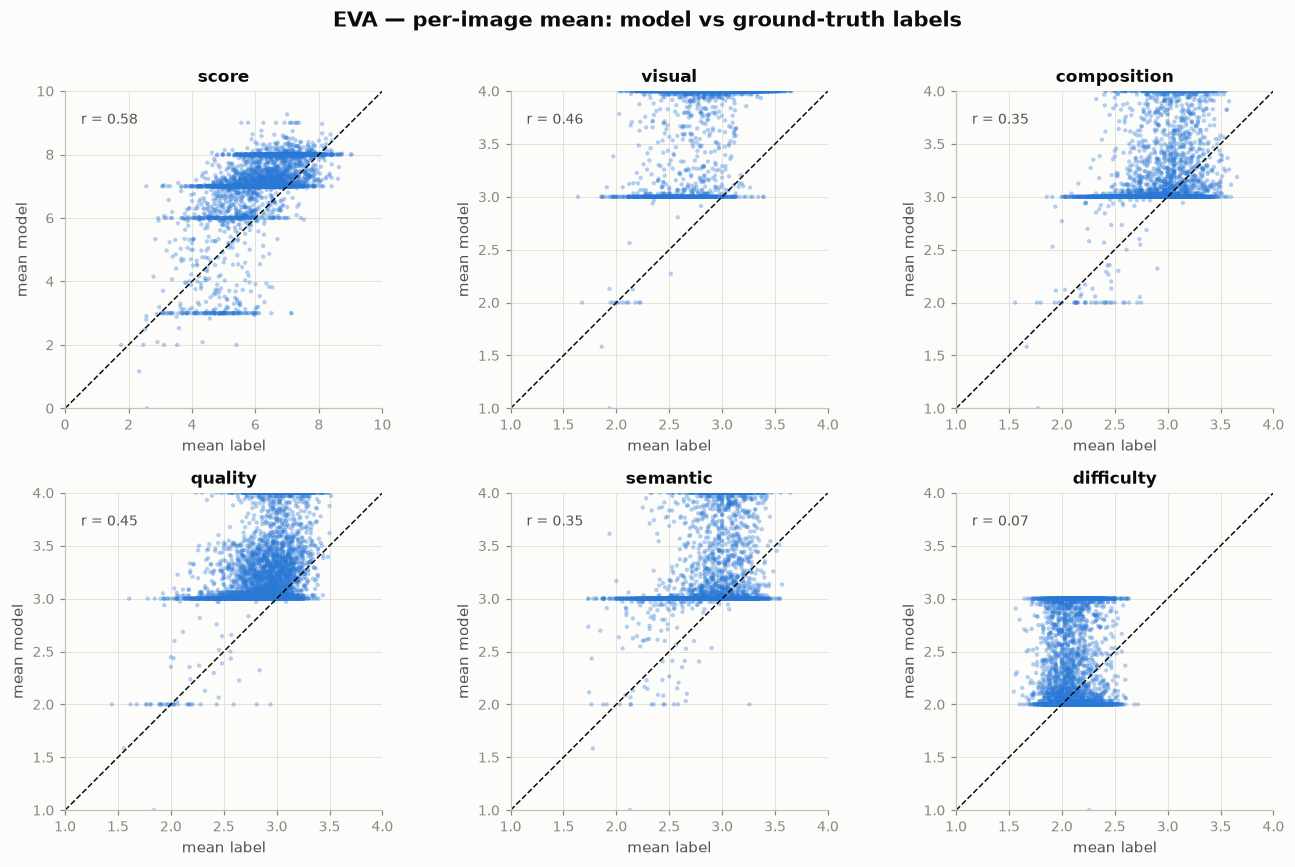

In [11]:
nr, nc = grid_shape(len(DIMS))
fig, axes = plt.subplots(nr, nc, figsize=(4.1 * nc, 3.9 * nr), squeeze=False)
for ax, dim in zip(axes.flat, DIMS):
    g = paired(DF, dim).groupby("imageName").agg(h=("gt", "mean"), v=("pred", "mean"))
    grid = GRIDS[dim]; lo, hi = grid[0], grid[-1]
    ax.scatter(g["h"], g["v"], s=8, color=BLUE, alpha=0.35, edgecolor="none")
    ax.plot([lo, hi], [lo, hi], color=INK, lw=1, ls="--")
    r = stats.pearsonr(g["v"], g["h"])[0] if g["v"].std() > 0 else np.nan
    ax.annotate(f"r = {r:.2f}", xy=(0.05, 0.93), xycoords="axes fraction", va="top",
                fontsize=9, color=SECONDARY)
    ax.set_title(dim); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal", "box")
    ax.set_xlabel("mean label"); ax.set_ylabel("mean model")
for ax in axes.flat[len(DIMS):]:
    ax.set_visible(False)
fig.suptitle(f"{DATASET} — per-image mean: model vs ground-truth labels",
             fontsize=14, fontweight="bold", color=INK, y=1.005)
fig.tight_layout(); plt.show()

## 6 - Concrete over- and under-rated photographs

Where model and labels diverge most on `score`, restricted to photographs with at least 15 voters.

In [12]:
g = (paired(DF, PRIMARY).groupby("imageName")
     .agg(n=("gt", "size"), mean_label=("gt", "mean"), mean_model=("pred", "mean")))
g["gap"] = g["mean_model"] - g["mean_label"]
g = g[g["n"] >= MIN_N].round(3)
print(f"{PRIMARY}: {ITEM_WORD}s the model rates FAR ABOVE the labels (top over-rating)")
print(g.sort_values("gap", ascending=False).head(8).to_string())
print(f"\n{PRIMARY}: {ITEM_WORD}s the model rates FAR BELOW the labels (top under-rating)")
print(g.sort_values("gap").head(8).to_string())
print("\nclosest agreement (|gap| smallest):")
print(g.reindex(g["gap"].abs().sort_values().index).head(8).to_string())

score: photographs the model rates FAR ABOVE the labels (top over-rating)
            n  mean_label  mean_model   gap
imageName                                  
72834      32       2.562       7.000 4.438
170900     34       3.059       7.000 3.941
713683     30       3.100       7.033 3.933
475051     32       3.094       7.000 3.906
436772     31       3.226       7.000 3.774
761213     32       3.312       7.000 3.688
909189     30       3.567       7.100 3.533
31044      36       5.556       9.000 3.444

score: photographs the model rates FAR BELOW the labels (top under-rating)
            n  mean_label  mean_model    gap
imageName                                   
648066     38       7.132       3.000 -4.132
764393     31       7.129       3.000 -4.129
570684     30       6.500       3.000 -3.500
77359      35       5.400       2.000 -3.400
765684     34       6.118       3.000 -3.118
156850     34       6.059       3.000 -3.059
304967     35       5.971       2.943 -3.029
55518

## Verdict

In [13]:
rows = {dim: agreement(DF, dim) for dim in DIMS}
overall = pd.Series({
    "mean MAE (native units)": np.mean([rows[d]["mae"] for d in DIMS]),
    "mean label-noise floor": np.mean([rows[d]["label_noise_mae"] for d in DIMS]),
    f"mean {TOL_LABEL} hit rate": np.mean([rows[d]["within_tol"] for d in DIMS]),
    "mean exact-match rate": np.mean([rows[d]["exact"] for d in DIMS]),
    "mean Pearson r": np.mean([rows[d]["pearson"] for d in DIMS]),
    "mean bias (native units)": np.mean([rows[d]["bias"] for d in DIMS]),
})
print(f"===== {DATASET} · persona T=0.7 vs ground-truth labels =====")
print(overall.round(3).to_string())
beat = [d for d in DIMS if rows[d]["mae"] < rows[d]["label_noise_mae"]]
print(f"\naxes where the model beats the label-noise floor: {len(beat)}/{len(DIMS)}"
      + (f"  ({', '.join(beat)})" if beat else ""))

===== EVA · persona T=0.7 vs ground-truth labels =====
mean MAE (native units)    0.799
mean label-noise floor     0.608
mean within 1 hit rate     0.855
mean exact-match rate      0.423
mean Pearson r             0.155
mean bias (native units)   0.509

axes where the model beats the label-noise floor: 0/6


### Notes
- Ground truth here is the `gt_*` field in the log — the per-voter label the pipeline recorded for each `(photograph, voter)` task; predictions are compared to the exact label that voter gave, not to an image average.
- Decoding was effectively greedy even at T=0.7 (`Qwen2-VL` ships `top_k=1, top_p=0.001`, not overridden here), so the model gives one deterministic answer per persona.
- The label-noise floor is a demanding reference: it already knows each image's mean label, which the model never sees.
- MAE and bias are in each axis's native units, so they are not comparable across axes of different scales; use the hit rates and Pearson r for that.